### 42028 : Deep Learning and CNN
### Assignment 1

| Name | Swapnil Ajit Chhatre |
| :--- | :--- |
| Student ID | 25675238 |
| Tutorial | 04 (Wednesday 12.00 - 15.00) |
| Tutor | Mr. Deep Patel |

#### Aim
- To develop SVM and Neural Network classifiers for handwritten mathematical symbol classification.
- To use Histogram Of Oriented Gradients (HoG), Local Binary Pattern (LBP), Raw images/pixels, and any other feature for classification

### Contents
1. Section 1 : ANN with Raw Pixels
2. Section 2 : ANN with HoG
3. Section 3 : ANN with LBP

### File Outcome
*Using Artificial Neural Network algorithm with Raw Pixels, HoG, and LBP features.*

### Libraries

In [1]:
!pip install opencv-python --quiet

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
autogluon-multimodal 1.5.0 requires nvidia-ml-py3<8.0,>=7.352.0, which is not installed.
autogluon-timeseries 1.5.0 requires chronos-forecasting<2.4,>=2.2.2, which is not installed.
autogluon-timeseries 1.5.0 requires einops<1,>=0.7, which is not installed.
autogluon-timeseries 1.5.0 requires peft<0.18,>=0.13.0, which is not installed.
amazon-sagemaker-jupyter-ai-q-developer 1.2.9 requires numpy<=2.0.1, but you have numpy 2.4.3 which is incompatible.
amazon-sagemaker-sql-magic 0.1.4 requires numpy<2, but you have numpy 2.4.3 which is incompatible.
autogluon-common 1.5.0 requires numpy<2.4.0,>=1.25.0, but you have numpy 2.4.3 which is incompatible.
autogluon-core 1.5.0 requires numpy<2.4.0,>=1.25.0, but you have numpy 2.4.3 which is incompatible.
autogluon-features 1.5.0 requires numpy<2.4.0,>=1.25.0, but you have 

In [57]:
#Required libraries and global variables
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn import metrics
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense

#ANN cannot use class labels in string format, hence the labels need to be encoded using integers
#The class labels are = ['1', '8', 'C', 'N', 'R', '[', 'b', 'p', 'sqrt', 'y']
le = LabelEncoder()

### Section 1 : ANN with Raw Pixels

In [58]:
#Importing data
raw_pixel_x_train = np.load('./train/raw_pixel_train_images.npy')
raw_pixel_y_train = np.load('./train/raw_pixel_train_labels.npy')
raw_pixel_x_test = np.load('./test/raw_pixel_test_images.npy')
raw_pixel_y_test = np.load('./test/raw_pixel_test_labels.npy')

In [59]:
#Encoding the labels for raw pixels
raw_pixel_y_train_encoded = le.fit_transform(raw_pixel_y_train)
raw_pixel_y_test_encoded = le.fit_transform(raw_pixel_y_test)

In [60]:
#Defining the model
ann_model_raw_pixels = Sequential([
    Input(shape=(raw_pixel_x_train.shape[1],)),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

In [61]:
#Compiling the ANN
ann_model_raw_pixels.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [62]:
#Fitting the models on training data
raw_pixel_history = ann_model_raw_pixels.fit(
    raw_pixel_x_train,
    raw_pixel_y_train_encoded,
    epochs=50,
    verbose=0
)
print("ANN model trained on Raw Pixel")
print("Final training accuracy : ", raw_pixel_history.history['accuracy'][-1])
print("Final training loss : ", raw_pixel_history.history['loss'][-1])

ANN model trained on Raw Pixel
Final training accuracy :  0.10371428728103638
Final training loss :  2.3025290966033936


*It can be observed that ANN give very low accuracy and high loss with Raw Images as input*

In [63]:
raw_pixel_test_loss, raw_pixel_test_acc = ann_model_raw_pixels.evaluate(
    raw_pixel_x_test,
    raw_pixel_y_test_encoded
)

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0913 - loss: 2.3043


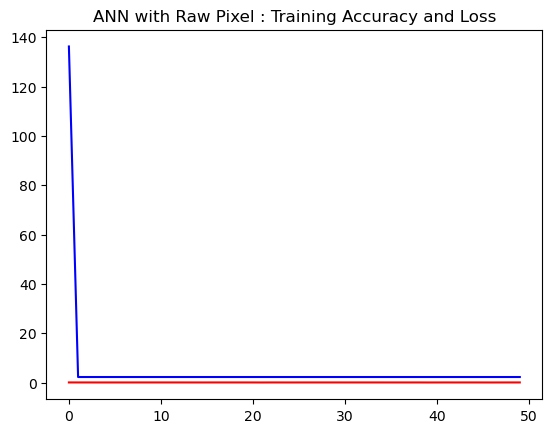

In [64]:
#Visualising training accuracy and loss
raw_pixel_train_acc = raw_pixel_history.history['accuracy']
raw_pixel_train_loss = raw_pixel_history.history['loss']
epochs = np.arange(50)

plt.plot(epochs, raw_pixel_train_acc, 'r', label='Training accuracy')
plt.plot(epochs, raw_pixel_train_loss, 'b', label='Training loss')
plt.title('ANN with Raw Pixel : Training Accuracy and Loss')
plt.show()

In [65]:
#Improving performance of ANN with Raw Pixels through normalization
raw_pixel_x_train_normalized = raw_pixel_x_train/255.0

In [67]:
#Re - defining the model
ann_model_raw_pixels = Sequential([
    Input(shape=(raw_pixel_x_train.shape[1],)),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])
#Re - compiling the ANN
ann_model_raw_pixels.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [68]:
#Fitting the models on training data
raw_pixel_normalized_history = ann_model_raw_pixels.fit(
    raw_pixel_x_train_normalized,
    raw_pixel_y_train_encoded,
    epochs=50,
    verbose=0
)
print("ANN model trained on Normalized Raw Pixel")
print("Final training accuracy : ", raw_pixel_normalized_history.history['accuracy'][-1])
print("Final training loss : ", raw_pixel_normalized_history.history['loss'][-1])

2026-03-26 20:58:58.637898: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 28350000 exceeds 10% of free system memory.


ANN model trained on Normalized Raw Pixel
Final training accuracy :  0.897428572177887
Final training loss :  0.36159905791282654


In [69]:
raw_pixel_test_loss, raw_pixel_test_acc = ann_model_raw_pixels.evaluate(
    raw_pixel_x_test,
    raw_pixel_y_test_encoded
)

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8127 - loss: 99.5003 


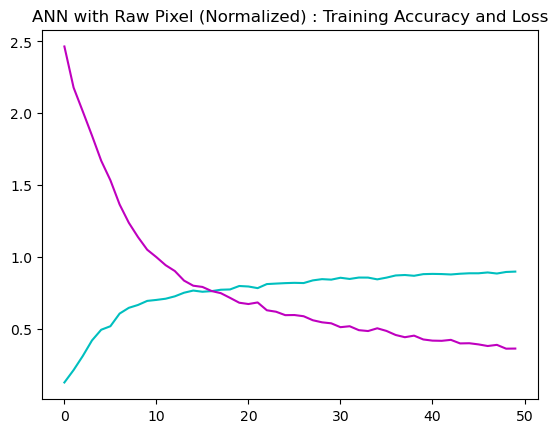

In [70]:
#Visualising training accuracy and loss
raw_pixel_train_acc = raw_pixel_normalized_history.history['accuracy']
raw_pixel_train_loss = raw_pixel_normalized_history.history['loss']
epochs = np.arange(50)

plt.plot(epochs, raw_pixel_train_acc, 'c', label='Training accuracy')
plt.plot(epochs, raw_pixel_train_loss, 'm', label='Training loss')
plt.title('ANN with Raw Pixel (Normalized) : Training Accuracy and Loss')
plt.show()

### Section 2 : ANN with HoG

In [71]:
#Importing data
hog_x_train = np.load('./train/hog_train_images.npy')
hog_y_train = np.load('./train/hog_train_labels.npy')
hog_x_test = np.load('./test/hog_test_images.npy')
hog_y_test = np.load('./test/hog_test_labels.npy')

In [72]:
#Encoding labels
hog_y_train_encoded = le.fit_transform(hog_y_train)
hog_y_test_encoded = le.fit_transform(hog_y_test)

In [73]:
#Compiling model
ann_model_hog = Sequential([
    Input(shape=(hog_x_train.shape[1],)),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

In [74]:
#Compiling ANN model
ann_model_hog.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [75]:
#Fitting the model on training data
hog_history = ann_model_hog.fit(
    hog_x_train,
    hog_y_train_encoded,
    epochs=50,
    verbose=0
)
print("ANN model trained on HoG features")
print("Final training accuracy : ", hog_history.history['accuracy'][-1])
print("Final training loss : ", hog_history.history['loss'][-1])

ANN model trained on HoG features
Final training accuracy :  0.9574285745620728
Final training loss :  0.14473259449005127


In [76]:
hog_test_loss, hog_test_acc = ann_model_hog.evaluate(
    hog_x_test,
    hog_y_test_encoded
)

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9253 - loss: 0.2188


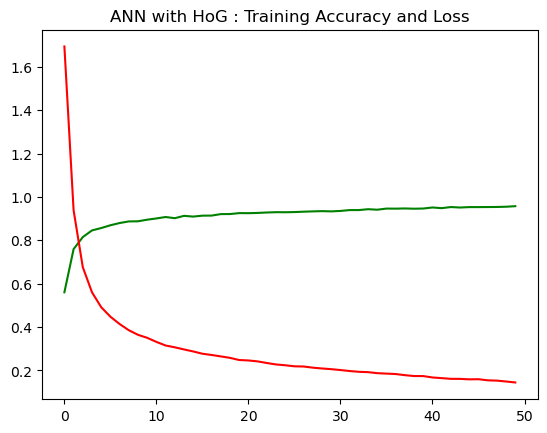

In [77]:
#Visualising training accuracy and loss
hog_train_acc = hog_history.history['accuracy']
hog_train_loss = hog_history.history['loss']
epochs = np.arange(50)

plt.plot(epochs, hog_train_acc, 'g', label='Training accuracy')
plt.plot(epochs, hog_train_loss, 'r', label='Training loss')
plt.title('ANN with HoG : Training Accuracy and Loss')
plt.show()

### Section 3 : ANN with LBP

In [78]:
#Importing data
lbp_x_train = np.load('./train/lbp_train_images.npy')
lbp_y_train = np.load('./train/lbp_train_labels.npy')
lbp_x_test = np.load('./test/lbp_test_images.npy')
lbp_y_test = np.load('./test/lbp_test_labels.npy')

In [79]:
#Encoding labels
lbp_y_train_encoded = le.fit_transform(lbp_y_train)
lbp_y_test_encoded = le.fit_transform(lbp_y_test)

In [80]:
#Defining model for ANN with LBP
ann_model_lbp = Sequential([
    Input(shape=(lbp_x_train.shape[1],)),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

In [81]:
#Compiling model
ann_model_lbp.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [82]:
#Fitting model of training data
lbp_history = ann_model_lbp.fit(
    lbp_x_train,
    lbp_y_train_encoded,
    epochs=50,
    verbose=0
)
print("ANN model trained on LBP features")
print("Final training accuracy : ", lbp_history.history['accuracy'][-1])
print("Final training loss : ", lbp_history.history['loss'][-1])

ANN model trained on LBP features
Final training accuracy :  0.8191428780555725
Final training loss :  0.5313776135444641


In [83]:
#Evaluating model on testing data
lbp_test_loss, lbp_test_acc = ann_model_lbp.evaluate(
    lbp_x_test,
    lbp_y_test_encoded
)

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7987 - loss: 0.5847


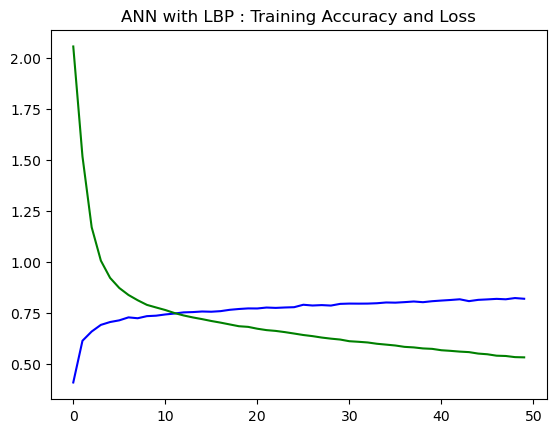

In [84]:
#Visualising training accuracy and loss
lbp_train_acc = lbp_history.history['accuracy']
lbp_train_loss = lbp_history.history['loss']
epochs = np.arange(50)

plt.plot(epochs, lbp_train_acc, 'b', label='Training accuracy')
plt.plot(epochs, lbp_train_loss, 'g', label='Training loss')
plt.title('ANN with LBP : Training Accuracy and Loss')
plt.show()